In [6]:
# ================================
# Cell 1: Imports
# ================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

np.random.seed(42)

In [7]:
import os

SAVE_PATH = r"D:\CODING\data mining\lab12"
os.makedirs(SAVE_PATH, exist_ok=True)

In [8]:
# ================================
# Cell 2: Load + Preprocess
# ================================
def load_data(loader):
    data = loader()
    X, y = data.data, data.target
    
    X = StandardScaler().fit_transform(X)
    
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# ================================
# Cell 3: Models
# ================================
def get_models():
    lr = LogisticRegression(max_iter=1000)
    dt = DecisionTreeClassifier()
    rf = RandomForestClassifier()
    bag = BaggingClassifier()
    ada = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    
    vote = VotingClassifier(
        estimators=[("lr", lr), ("rf", rf), ("gb", gb)],
        voting="soft"
    )

    return {
        "LR": lr,
        "DT": dt,
        "Bagging": bag,
        "RF": rf,
        "AdaBoost": ada,
        "GB": gb,
        "Voting": vote
    }

In [10]:
# ================================
# Cell 4: Evaluation
# ================================
def evaluate(models, X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        t = time.time() - start

        pred = model.predict(X_test)

        results[name] = {
            "Accuracy": accuracy_score(y_test, pred),
            "F1": f1_score(y_test, pred, average="weighted"),
            "Time": t
        }

    return pd.DataFrame(results).T

In [11]:
# ================================
# Cell 5: Run
# ================================
datasets = {
    "Breast Cancer": load_breast_cancer,
    "Iris": load_iris
}

all_results = {}

for name, loader in datasets.items():
    X_train, X_test, y_train, y_test = load_data(loader)
    models = get_models()
    
    df = evaluate(models, X_train, X_test, y_train, y_test)
    all_results[name] = df
    
    print("\n", name)
    print(df)


 Breast Cancer
          Accuracy        F1      Time
LR        0.973684  0.973621  0.027043
DT        0.947368  0.947368  0.015243
Bagging   0.956140  0.956036  0.132429
RF        0.964912  0.964738  0.448050
AdaBoost  0.964912  0.964738  0.355898
GB        0.956140  0.956036  1.091729
Voting    0.964912  0.964738  1.690033

 Iris
          Accuracy        F1      Time
LR        1.000000  1.000000  0.016206
DT        1.000000  1.000000  0.000000
Bagging   1.000000  1.000000  0.056451
RF        1.000000  1.000000  0.376589
AdaBoost  0.933333  0.933333  0.210034
GB        1.000000  1.000000  0.755510
Voting    1.000000  1.000000  1.129528


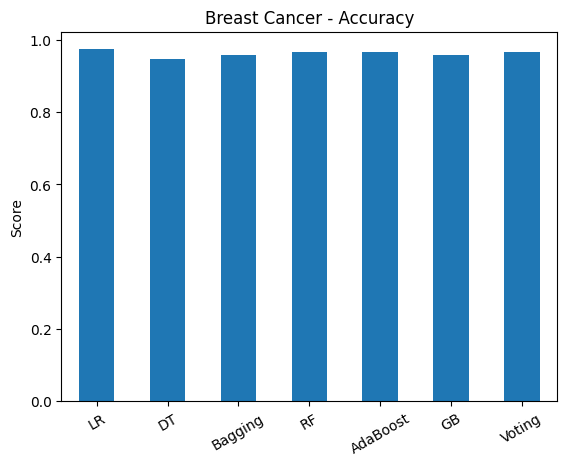

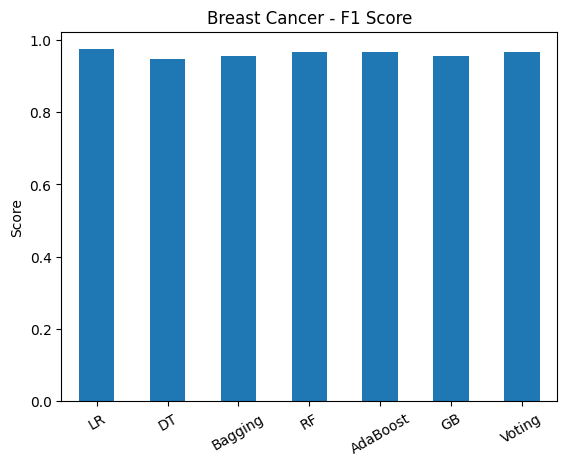

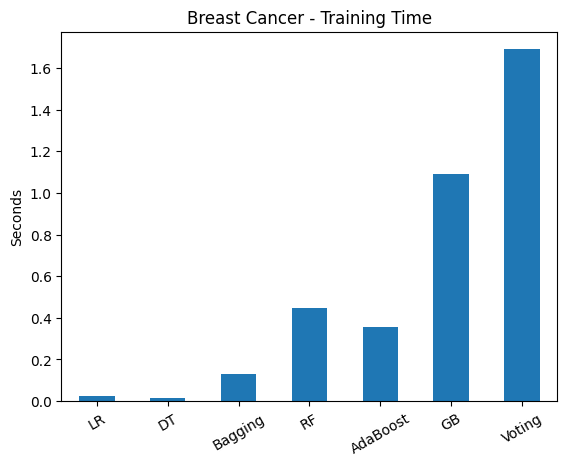

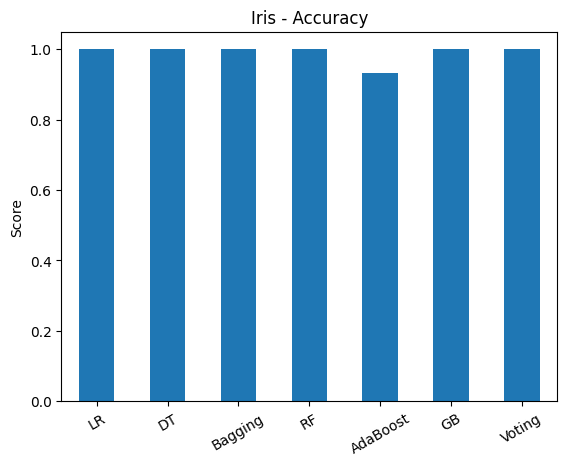

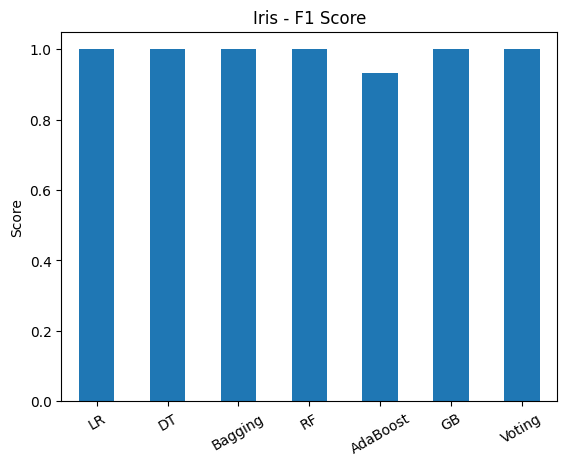

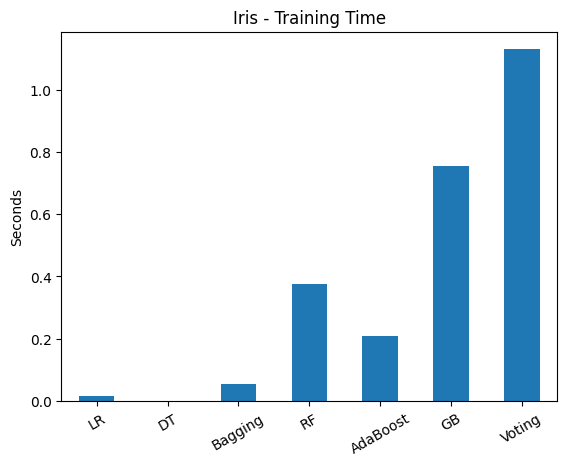

In [12]:
# ================================
# Cell 6: SIMPLE VISUALIZATIONS
# ================================
for name, df in all_results.items():
    
    # ---- Accuracy Plot ----
    df["Accuracy"].plot(kind="bar")
    plt.title(f"{name} - Accuracy")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    plt.show()

    # ---- F1 Score Plot ----
    df["F1"].plot(kind="bar")
    plt.title(f"{name} - F1 Score")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    plt.show()

    # ---- Training Time ----
    df["Time"].plot(kind="bar")
    plt.title(f"{name} - Training Time")
    plt.ylabel("Seconds")
    plt.xticks(rotation=30)
    plt.show()

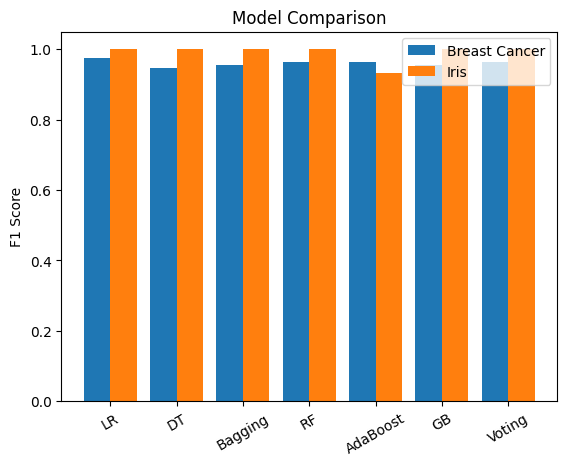

In [13]:
# ================================
# Cell 7: Comparison Plot
# ================================
models = list(all_results["Breast Cancer"].index)

bc = all_results["Breast Cancer"]["F1"]
iris = all_results["Iris"]["F1"]

x = np.arange(len(models))

plt.bar(x - 0.2, bc, width=0.4, label="Breast Cancer")
plt.bar(x + 0.2, iris, width=0.4, label="Iris")

plt.xticks(x, models, rotation=30)
plt.ylabel("F1 Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

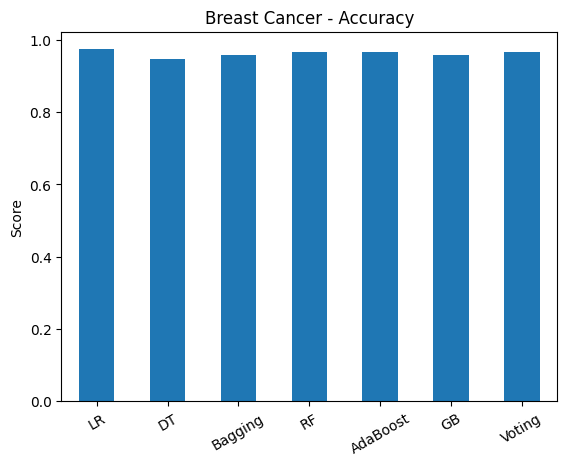

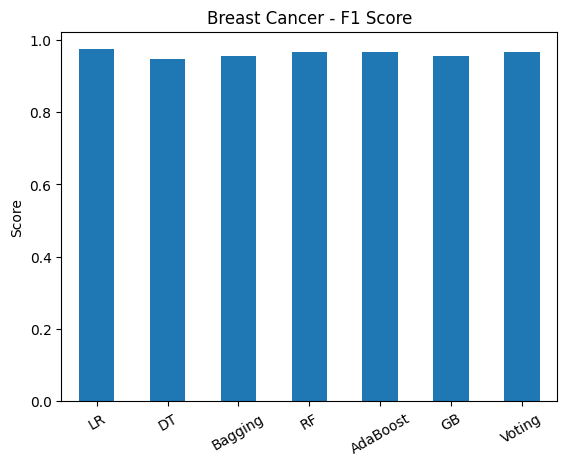

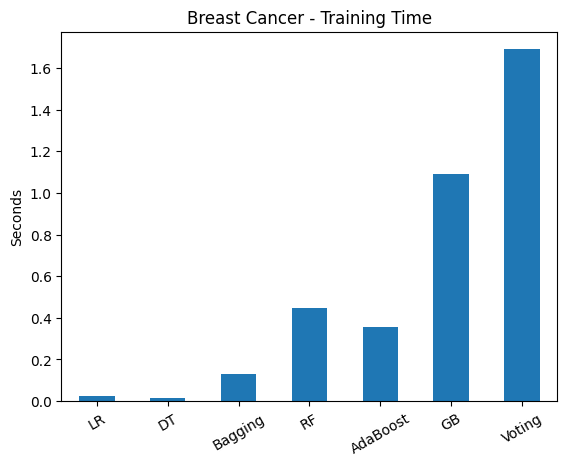

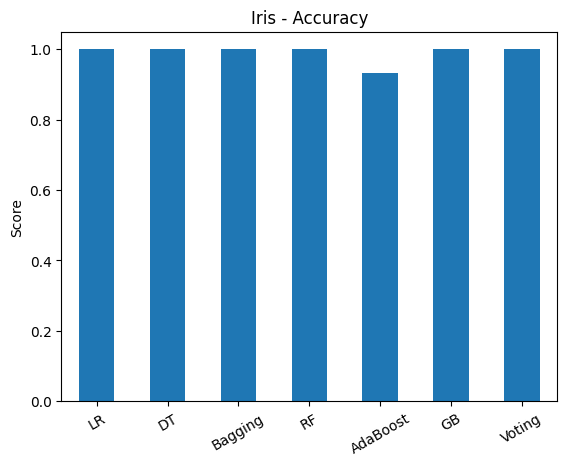

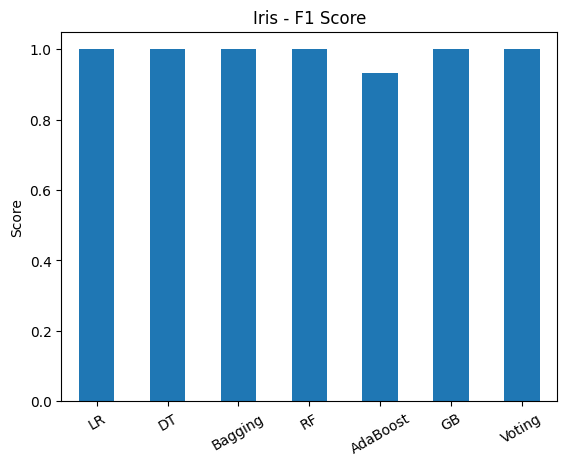

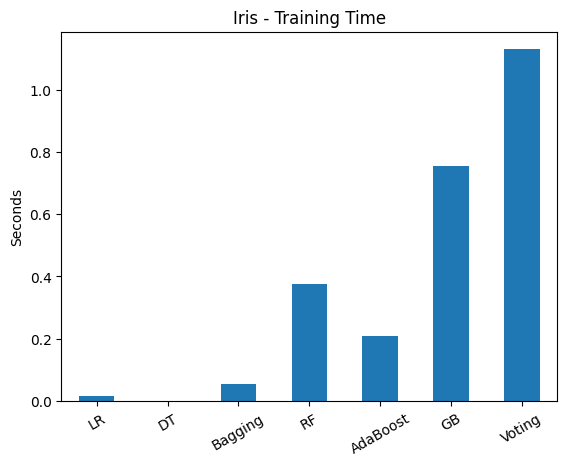

In [14]:
 
# Cell 6: SIMPLE VISUALIZATIONS (WITH SAVE)
for name, df in all_results.items():
    
    safe_name = name.replace(" ", "_")

    # ---- Accuracy Plot ----
    df["Accuracy"].plot(kind="bar")
    plt.title(f"{name} - Accuracy")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    
    plt.savefig(f"{SAVE_PATH}\\{safe_name}_accuracy.png")
    plt.show()

    # ---- F1 Score Plot ----
    df["F1"].plot(kind="bar")
    plt.title(f"{name} - F1 Score")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    
    plt.savefig(f"{SAVE_PATH}\\{safe_name}_f1.png")
    plt.show()

    # ---- Training Time ----
    df["Time"].plot(kind="bar")
    plt.title(f"{name} - Training Time")
    plt.ylabel("Seconds")
    plt.xticks(rotation=30)
    
    plt.savefig(f"{SAVE_PATH}\\{safe_name}_time.png")
    plt.show()

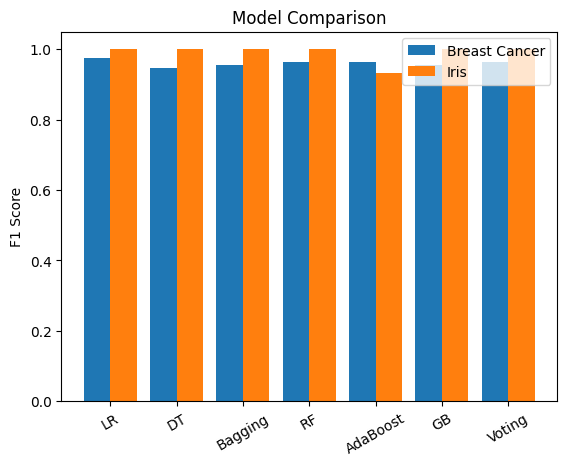

In [15]:
# ================================
# Cell 7: Comparison Plot (SAVE)
# ================================
models = list(all_results["Breast Cancer"].index)

bc = all_results["Breast Cancer"]["F1"]
iris = all_results["Iris"]["F1"]

x = np.arange(len(models))

plt.bar(x - 0.2, bc, width=0.4, label="Breast Cancer")
plt.bar(x + 0.2, iris, width=0.4, label="Iris")

plt.xticks(x, models, rotation=30)
plt.ylabel("F1 Score")
plt.title("Model Comparison")
plt.legend()

plt.savefig(f"{SAVE_PATH}\\comparison.png")
plt.show()